In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [29]:
##Ethanol Bottle_012.csv, Storage Bag.csv, Salsa Container_010.csv, nylon string.csv, string_006.csv, Zip Tie_014.csv, 
##Fishing Line_013.csv, Water bottle_014.csv, Heat Sealable Film_009.csv, Gloves.csv, Glove 2.csv
def load_IR_csv(name):
    d = pd.read_csv(f"NK_AJ_AW/{name}.csv", skiprows=1)
    d.columns = ["wn", "T"]
    return d
Eth_bottle_IR= load_IR_csv("string_006")
print(Eth_bottle_IR.head)


<bound method NDFrame.head of           wn      T
0     4000.0  97.93
1     3999.0  97.92
2     3998.0  97.92
3     3997.0  97.92
4     3996.0  97.92
...      ...    ...
3596   404.0  86.48
3597   403.0  86.56
3598   402.0  86.60
3599   401.0  86.28
3600   400.0  85.59

[3601 rows x 2 columns]>


In [25]:
##$Ethanol bottle.csv, $String.csv
def load_DSC(name):
    d = pd.read_csv(f"N_A_A/{name}.csv", skiprows=1,encoding="latin-1")
    d.columns = ["T", "Q"]
    return d
Eth_bottle_DSC = load_DSC("$Ethanol bottle")
print(Eth_bottle_DSC.head)

<bound method NDFrame.head of               T           Q
0     29.976358  -51.040394
1     30.274673 -126.273308
2     30.565733 -216.632401
3     30.864202 -290.613464
4     31.199203 -286.209167
..          ...         ...
806  298.576324  -62.470295
807  298.909271  -62.696388
808  299.242188  -62.951763
809  299.574982  -63.257980
810  299.907806  -63.573112

[811 rows x 2 columns]>


In [26]:
FTIR = {
    "Ethanol Bottle_012": "Ethanol bottle", "Storage Bag": "Storage bag",
    "Salsa Container_010": "Salsa container", "nylon string": '"Nylon" string',
    "string_006": "String", "Zip Tie_014": "Zip tie", "Fishing Line_013": "Fishing line",
    "Water bottle_014": "Water bottle", "Heat Sealable Film_009": "Heat-sealable film",
    "Gloves": "Glove 1", "Glove 2": "Glove 2",
}

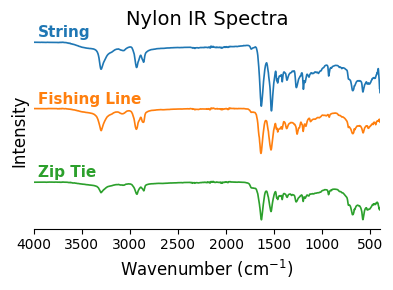

In [47]:
##Ziptie,Sting,Fishing line all had nylon according to IR##
##STACKED SPECTRA##
spectra = [
    ("string_006", "String"),
    ("Fishing Line_013", "Fishing Line"),
    ("Zip Tie_014", "Zip Tie"),
]
OFFSET = 18
fig, ax = plt.subplots(figsize=(4,3))
 
n = len(spectra)
for i, (name, label) in enumerate(spectra):
    d = load_IR_csv(name)
    shift = (n - 1 - i) * OFFSET 
    line, = ax.plot(d["wn"], d["T"] + shift, lw=1.2)
    ax.text(3950, d["T"].iloc[:50].mean() + shift + 1.2, label, color=line.get_color(), fontsize=11, fontweight="bold")


 
ax.set_xlim(4000, 400)                     
ax.set_xlabel("Wavenumber (cm$^{-1}$)", fontsize=12)
ax.set_ylabel("Intensity", fontsize=12)
ax.set_title("Nylon IR Spectra", fontsize=14)
ax.set_yticks([])                 
ax.spines[["top", "right", "left"]].set_visible(False)
 
plt.tight_layout()
plt.savefig("stacked_ir_spectra.png", dpi=300)
plt.show()



In [ ]:
##Looking at the FTIR SPECTRA with reported same material##



In [ ]:
##DSC with peaks labeled (exo up; endo down)##
# Each peak: (symbol, "max" for exothermic / "min" for endothermic, temperature window [C] to search)
dsc_samples = [
    ("$Ethanol bottle", "Ethanol bottle", [("T_m", "min", (110, 150)), ("T_c", "max", (200, 260))]),
    ("$Storage bag",    "Storage bag",    [("T_m", "min", (100, 120)), ("T_c", "max", (200, 260))]),
    ("$String",         "String",         [("T_c", "max", (200, 245)), ("T_m", "min", (245, 270))]),
    ("$Ziptie",         "Zip tie",        [("T_c", "max", (200, 245)), ("T_m", "min", (245, 270))]),
    ("$Fishing line",   "Fishing line",   [("T_{m1}", "min", (180, 195)), ("T_{m2}", "min", (200, 218)),
                                           ("T_c", "max", (215, 235))]),
]
colors = {"max": "red", "min": "blue"}

for name, label, peaks in dsc_samples:
    d = load_DSC(name)
    d = d.apply(pd.to_numeric, errors="coerce").dropna()   # drop the units row
    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.plot(d["T"], d["Q"], lw=1.5, color="black")

    steady = d[d["T"] > 45]["Q"]                             # ignore start-up transient for scaling
    dy = 0.15 * (steady.max() - steady.min())
    for sym, kind, (tlo, thi) in peaks:
        win = d[(d["T"] >= tlo) & (d["T"] <= thi)]
        pk = win.loc[win["Q"].idxmax() if kind == "max" else win["Q"].idxmin()]
        offset = dy if kind == "max" else -dy               # label above exo peaks, below endo dips
        ax.annotate(f"${sym}$ = {pk['T']:.1f} °C", xy=(pk["T"], pk["Q"]), xytext=(pk["T"] - 60, pk["Q"] + offset),
                    arrowprops=dict(arrowstyle="->", color=colors[kind], lw=1.5), color=colors[kind], fontsize=11)

    ax.set_ylim(steady.min() - 2 * dy, steady.max() + 2 * dy)
    ax.set_xlabel("Temperature (°C)", fontsize=12)
    ax.set_ylabel("Heat Flow (mW)", fontsize=12)
    ax.set_title(f"{label} DSC", fontsize=14)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"dsc_{label.replace(' ', '_').lower()}.png", dpi=300)
    plt.show()
